In [1]:
import pyvrp
import pyvrp.plotting
import pyvrp.stop
import osmnx as ox
import random
import networkx as nx
import matplotlib.pyplot as plt
import igraph as ig
from typing import Tuple, Dict

In [2]:
graph = ox.load_graphml("data/lausanne.graphml")

In [3]:
# update the node IDs to start from 1 and be consecutive
# mapping = {node: i + 1 for i, node in enumerate(graph.nodes())}
# graph = nx.relabel_nodes(graph, mapping)

In [4]:
center_lat, center_lon = 46.5225, 6.6328
# lausanne_post_offices = [
#     (46.51786477124877, 6.634763001182209), # train station
#     (46.52280567146395, 6.63484387895323), # Riponne
#     (46.522894798355864, 6.629079677111272), # Sévelin
#     (46.51567504637278, 6.616255947170737), # Avenue de Cour
#     (46.51926275908995, 6.636592569361496), # Saint-François
#     (46.52759603474043, 6.605310440911157), # Malley
#     (46.52474383288413, 6.5894279622916585), # Bourdonnette
#     (46.53290073179973, 6.6314276590463965), # Pontaise
#     (46.52649108372711, 6.657349467139207), # Chailly
#     (46.53385993374889, 6.650884859700522), # Sallaz
#     (46.51189489849091, 6.640543342774893), # Montchoisi
#     (46.50894136727424, 6.631788612292283), # Ouchy
#   ]


In [5]:
# # for each of the lausanne post offices, identify the node closest to it, then randomly sample 10 nodes that are within 1km of it, and add them to the list of pairs as (post office node, random node)
# pairs = []

# for lat, lon in lausanne_post_offices:
#     post_office_node = ox.distance.nearest_nodes(graph, lon, lat)
    
#     # Calculate the euclidean distance from the post office node to all other nodes in the graph
#     def distance_km(node):
#         lat_km = (node["y"] - lat) * 111.0
#         lon_km = (node["x"] - lon) * 111.0 * 0.7
#         return (lat_km**2 + lon_km**2) ** 0.5
    
#     nodes_in_radius = [
#         n
#         for n in graph.nodes()
#         if distance_km(graph.nodes[n]) <= 1.0
#     ]

#     if len(nodes_in_radius) < 2:
#         nodes_in_radius = list(graph.nodes())

#     for _ in range(10):
#         random_node = random.choice(nodes_in_radius)
#         pairs.append((post_office_node, random_node))

In [6]:
# volume_capacity = 5*2*1.5   # vehicle dimensions in [m]
# weight_capacity = 500       # in [kg]
# service_time = 5    # time required at stop, in minutes
# starting_time = 420 # 7AM
# ending_time = 720   # 12AM
# start_location = 0  # depot
# end_location = 0    # depot

In [7]:
# pairs

In [8]:
# COORDS = [(graph.nodes[n]["y"], graph.nodes[n]["x"]) for n in graph.nodes()]
# DELIVERIES = [5 for _ in range(len(pairs))]

In [9]:
# COORDS

In [10]:
# m = pyvrp.Model()

# for office in lausanne_post_offices:
#     m.add_depot(x=office[0], y=office[1])

# for frm, to in pairs:
#     m.add_client(x=COORDS[to][0], y=COORDS[to][1], delivery=DELIVERIES[0])
# # m.add_depot(x=COORDS[0][0], y=COORDS[0][1])

# m.add_vehicle_type(len(lausanne_post_offices), capacity=30)

# # m.add_client(x=COORDS[1][0], y=COORDS[1][1], delivery=DELIVERIES[0])
# # m.add_client(x=COORDS[2][0], y=COORDS[2][1], delivery=DELIVERIES[1])



In [11]:
# for frm in m.locations:
#     for to in m.locations:
#         if frm != to:
#             m.add_edge(frm, to, distance=1)  # unit distances

# res = m.solve(stop=pyvrp.stop.MaxRuntime(5))  # one second of runtime

In [12]:
# pyvrp.plotting.plot_solution(res.best, m.data())

In [13]:
import pandas as pd

In [14]:
waste_per_centroid = 10


In [15]:
df = pd.read_csv("DI_final_clustered_centroids.csv")

In [16]:
COORDS = [(center_lat, center_lon)]
for n in range(500):
  COORDS.append((df.iloc[n]["centroid_lat"], df.iloc[n]["centroid_lon"]))


In [17]:
def networkx_to_igraph_with_indices(
    g: nx.MultiDiGraph,
) -> Tuple[ig.Graph, Dict[str, dict]]:
    """Convert networkx graph to igraph with bidirectional index mappings.

    Args:
        g: NetworkX MultiDiGraph

    Returns:
        Tuple of (igraph Graph, index mappings dict)
        Index mappings contain: node_nx_to_ig, node_ig_to_nx, edge_nx_to_ig, edge_ig_to_nx
    """
    e = ox.graph_to_gdfs(g, nodes=False, edges=True)
    nx.set_edge_attributes(g, {idx: idx for idx in e.index}, name="nx_edge_id")
    h = ig.Graph.from_networkx(g)

    idx_maps = {
        "node_nx_to_ig": {a: b for a, b in zip(h.vs()["_nx_name"], h.vs.indices)},
        "node_ig_to_nx": {b: a for a, b in zip(h.vs()["_nx_name"], h.vs.indices)},
        "edge_nx_to_ig": {a: b for a, b in zip(h.es()["nx_edge_id"], h.get_edgelist())},
        "edge_ig_to_nx": {b: a for a, b in zip(h.es()["nx_edge_id"], h.get_edgelist())},
    }

    return h, idx_maps

In [18]:
h, idx_maps = networkx_to_igraph_with_indices(graph)
nodes = ox.graph_to_gdfs(graph, nodes=True, edges=False)
nodes = nodes.loc[(nodes["street_count"] >= 3)]
nodes_ig = [idx_maps["node_nx_to_ig"][idx] for idx in nodes.index]

In [19]:
nodes_ig

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 74,
 75,
 76,
 77,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 98,
 99,
 101,
 102,
 103,
 104,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,
 185,
 186,
 187,
 188,
 189,
 190,
 191,
 1

In [20]:
df["node"] = ox.distance.nearest_nodes(graph, df["centroid_lon"], df["centroid_lat"])
df["centroid_waste"] = waste_per_centroid

In [21]:
node_df = df.groupby("node")["centroid_waste"].sum().reset_index()

# # Add the coordinates of the nodes to the node_df
node_df["x"] = node_df["node"].map(lambda n: graph.nodes[n]["x"])
node_df["y"] = node_df["node"].map(lambda n: graph.nodes[n]["y"])

In [22]:
# The node index is still the networkx node index, we need to convert it to the igraph node index
node_df["node_ig"] = node_df["node"].map(lambda n: idx_maps["node_nx_to_ig"][n])

In [23]:
node_df

,node,centroid_waste,x,y,node_ig
0,172251,20,6.586282,46.523797,0
1,280588,50,6.612766,46.517174,4
2,280595,40,6.617013,46.517935,6
3,280597,40,6.616263,46.518553,7
4,280612,70,6.624033,46.519380,9
...,...,...,...,...,...
1283,12816975428,10,6.598057,46.517880,4745
1284,12888784929,40,6.644881,46.588479,4749
1285,13078352791,10,6.657079,46.567771,4752
1286,13231877305,10,6.646214,46.515895,4767


In [24]:
depot_osm_node = ox.distance.nearest_nodes(graph, center_lon, center_lat)
depot_osm_node_ig = idx_maps["node_nx_to_ig"][depot_osm_node]

node_df["isdepot"] = False

# If the node corresponding to the depot is already in the node_df,
# we set the centroid_waste to 0 and isdepot to True, otherwise we add a new row with the depot node, centroid_waste of 0, and isdepot of True
if depot_osm_node in node_df["node"].values:
    node_df.loc[node_df["node"] == depot_osm_node, "centroid_waste"] = 0
    node_df.loc[node_df["node"] == depot_osm_node, "isdepot"] = True
else: 
  center_df = pd.DataFrame(
      {
          "node": [depot_osm_node],
          "node_ig": [depot_osm_node_ig],
          "centroid_waste": [0], 
          "x": [graph.nodes()[depot_osm_node]["x"]], 
          "y": [graph.nodes()[depot_osm_node]["y"]],
          "isdepot": [True]
      }
  )

  # add a row with node 0, x and y of the center closest node, and waste of 0

  node_df = pd.concat([center_df, node_df], ignore_index=True)  

In [25]:
node_df

,node,centroid_waste,x,y,node_ig,isdepot
0,172251,20,6.586282,46.523797,0,False
1,280588,50,6.612766,46.517174,4,False
2,280595,40,6.617013,46.517935,6,False
3,280597,40,6.616263,46.518553,7,False
4,280612,70,6.624033,46.519380,9,False
...,...,...,...,...,...,...
1283,12816975428,10,6.598057,46.517880,4745,False
1284,12888784929,40,6.644881,46.588479,4749,False
1285,13078352791,10,6.657079,46.567771,4752,False
1286,13231877305,10,6.646214,46.515895,4767,False


In [26]:
depot_osm_node_ig

270

In [27]:
e = ox.graph_to_gdfs(graph, nodes=False, edges=True)
nx.set_edge_attributes(graph, {idx: idx for idx in e.index}, name="nx_edge_id")
g_ig = ig.Graph.from_networkx(graph)

In [28]:
unique_ig_nodes = set(node_df["node_ig"].tolist())
od_distance = g_ig.distances(list(unique_ig_nodes), list(unique_ig_nodes), weights = "length")

In [29]:
# Find which node in the node_ig column appears twice
duplicate_nodes = node_df[node_df['node_ig'].duplicated(keep=False)]
duplicate_nodes

,node,centroid_waste,x,y,node_ig,isdepot


In [30]:
# Find indices inaccessible from depot (index 0)
inaccessible_indices = [i for i, dist in enumerate(od_distance[0]) if dist == float('inf')]
print(f"Indices with infinite distance from depot: {inaccessible_indices}")

Indices with infinite distance from depot: [379, 571, 633, 790, 805, 959, 1075, 1221, 1268]


In [38]:
m = pyvrp.Model()

# set the depot as the node 0 in node_df
depot = m.add_depot(x=node_df.loc[node_df["isdepot"], "x"].values[0], y=node_df.loc[node_df["isdepot"], "y"].values[0])

regular = m.add_profile(name="regular")
m.add_vehicle_type(15, capacity=5000, reload_depots=[depot], max_reloads = 10, profile=regular)

impossible_access = m.add_profile(name="impossible_access")

for _, row in node_df.iterrows():
  if not row["isdepot"]:
    if row["node_ig"] in inaccessible_indices:
      print(f"Node {row['node']} with ig index {row['node_ig']} is inaccessible from the depot, adding it as a client with required = False")
      m.add_client(x=row["x"], y=row["y"], delivery=int(row["centroid_waste"]), required = False)
    else:
      m.add_client(x=row["x"], y=row["y"], delivery=int(row["centroid_waste"]))


Node 258755811 with ig index 379 is inaccessible from the depot, adding it as a client with required = False
Node 269559113 with ig index 805 is inaccessible from the depot, adding it as a client with required = False
Node 275517095 with ig index 959 is inaccessible from the depot, adding it as a client with required = False
Node 282654083 with ig index 1075 is inaccessible from the depot, adding it as a client with required = False
Node 290288956 with ig index 1221 is inaccessible from the depot, adding it as a client with required = False


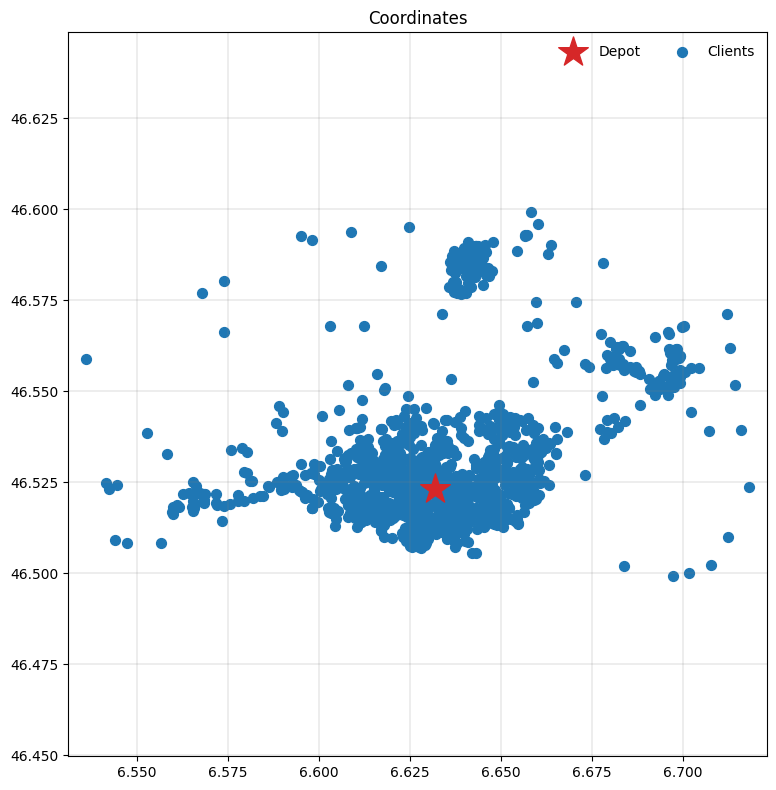

In [32]:
_, ax = plt.subplots(figsize=(8, 8))
pyvrp.plotting.plot_coordinates(m.data(), ax=ax)
plt.tight_layout()

In [39]:
for frm_idx, frm in enumerate(m.locations):
    for to_idx, to in enumerate(m.locations):
        # print(f"Adding edge from {frm_idx} to {to_idx}")
        duration = od_distance[frm_idx][to_idx]

        if duration == float("inf"):
            print(f"Edge from {frm_idx} to {to_idx} is inaccessible, adding it with infinite distance")
            duration = 999999
      
        m.add_edge(frm, to, distance=duration)

Edge from 0 to 379 is inaccessible, adding it with infinite distance
Edge from 0 to 571 is inaccessible, adding it with infinite distance
Edge from 0 to 633 is inaccessible, adding it with infinite distance
Edge from 0 to 790 is inaccessible, adding it with infinite distance
Edge from 0 to 805 is inaccessible, adding it with infinite distance
Edge from 0 to 959 is inaccessible, adding it with infinite distance
Edge from 0 to 1075 is inaccessible, adding it with infinite distance
Edge from 0 to 1221 is inaccessible, adding it with infinite distance
Edge from 0 to 1268 is inaccessible, adding it with infinite distance
Edge from 1 to 379 is inaccessible, adding it with infinite distance
Edge from 1 to 571 is inaccessible, adding it with infinite distance
Edge from 1 to 633 is inaccessible, adding it with infinite distance
Edge from 1 to 790 is inaccessible, adding it with infinite distance
Edge from 1 to 805 is inaccessible, adding it with infinite distance
Edge from 1 to 959 is inaccessi

In [40]:
res = m.solve(stop=pyvrp.stop.MaxRuntime(15), seed=42)

PyVRP v0.13.3

Solving an instance with:
    1 depot
    1287 clients
    15 vehicles (1 vehicle type)

    Iters    Time |      Current OK    Candidate OK         Best OK
H    2548      5s |      6509131  Y      6509131  Y      6506357  Y
H    7042     10s |      6487095  Y      7471942  Y      6485860  Y
H   11884     15s |      6481580  Y      6481862  Y      6479300  Y

Search terminated in 15.00s after 11885 iterations.
Best-found solution has cost 6479300.

Solution results
    # routes: 10
     # trips: 12
   # clients: 1282
   objective: 6479300
    distance: 6479300
    duration: 0
# iterations: 11885
    run-time: 15.00 seconds


In [41]:
res.best.num_missing_clients()

0

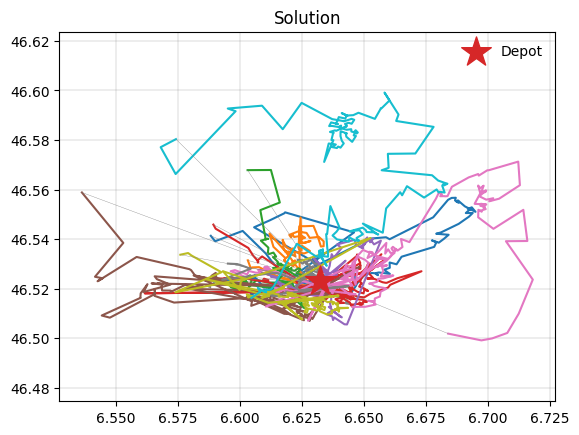

In [42]:
pyvrp.plotting.plot_solution(res.best, m.data())

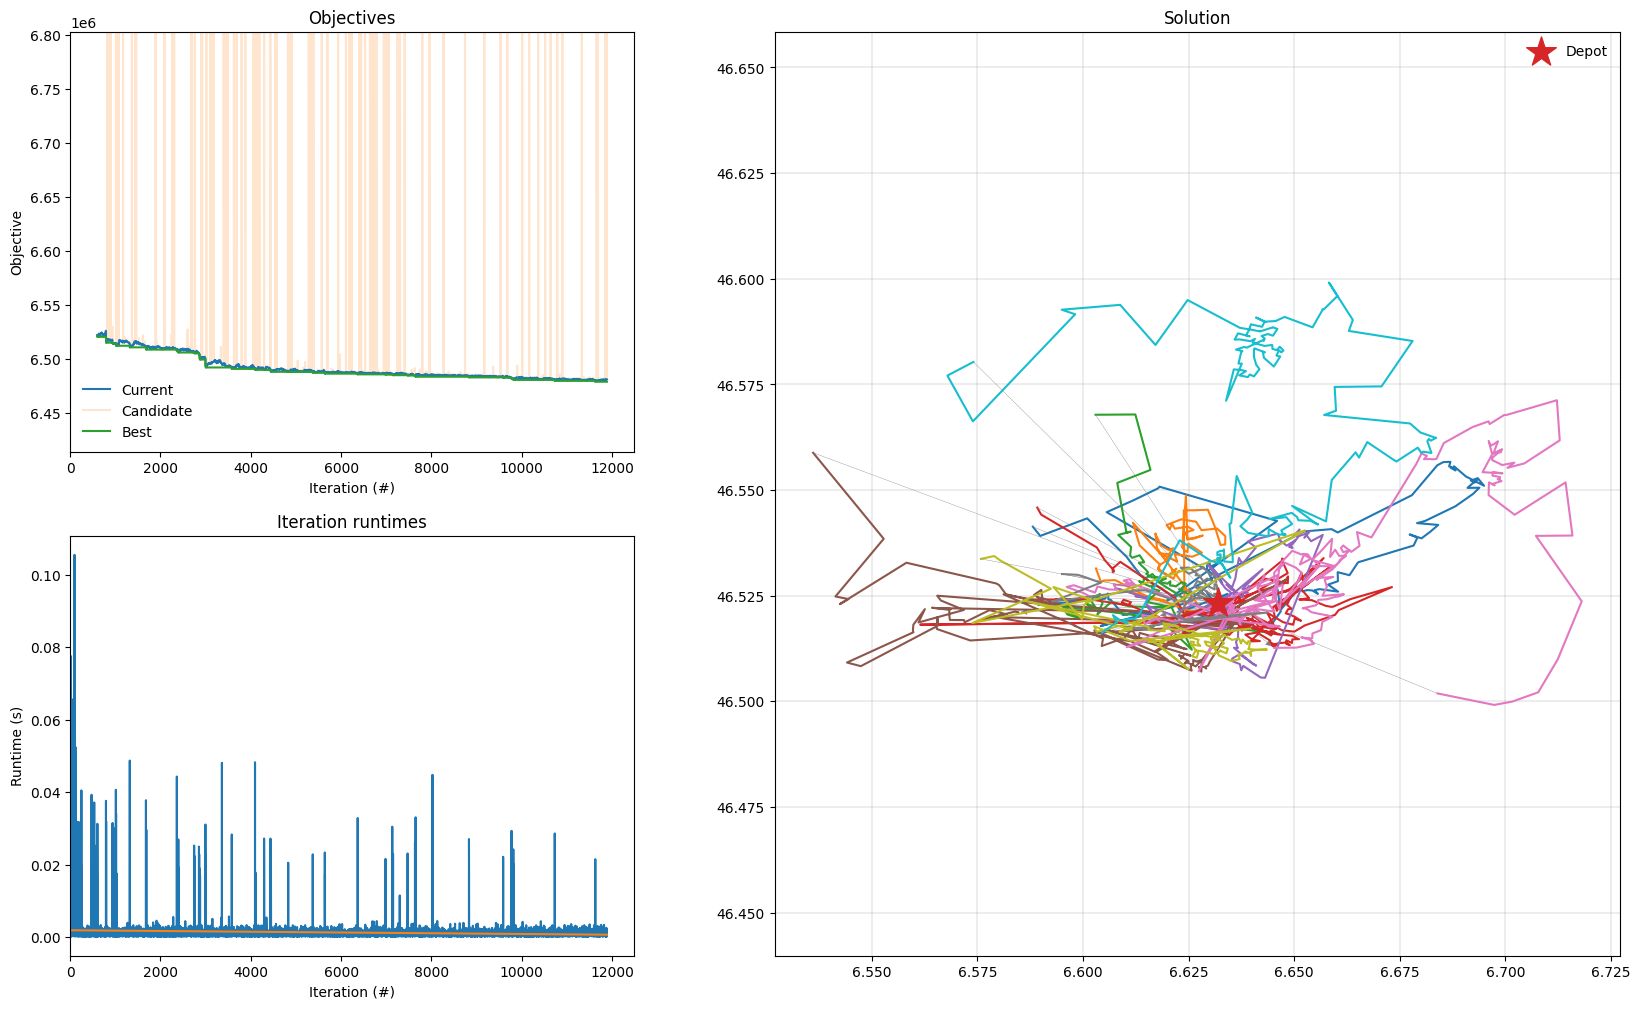

In [43]:
pyvrp.plotting.plot_result(res, m.data())

In [44]:
print(res.best)

Route #1: 235 676 1148 1204 842 156 157 895 894 1084 896 158 378 1218 983 859 121 865 382 185 449 489 479 1060 490 1215 136 1022 1025 451 1023 1024 1026 1027 805 673 1176 570 1245 20 882 915 916 776 1095 796 797 1158 1154 1155 817 1156 1152 512 360 511 1123 788 1124 1091 1092 1093 765 764 789 768 1097 814 816 815 763 564 883 563 832 565 566 1048 599 824 825 602 1058 601 258 936 935 247 59 89 90 943 794 641 642 45 531 890 13 41 140 139 7 199 196 984 985 1000 701 353 523 485 1142 634
Route #2: 132 606 1200 605 481 945 946 482 947 1079 1199 604 926 607 1276 608 674 952 609 611 950 951 949 610 133 1281 203 948 1193 477 240 228 925 202 1002 924 332 930 612 613 227 233 1016 1003 932 778 1007 1008 1135 1011 1006 1010 1012 1009 1013 1157 929 234 1153 931 923 988 675 1001 1103 1101 1102 1277 1221 1222 383 1263 19 897 1262 1264 621 359 371 1179 369 713
Route #3: 17 1173 1175 337 822 336 334 335 1172 861 862 863 517 1177 864 155 154 372 373 773 904 843 23 905 850 1251 358 996 965 703 704 706 705 

In [45]:
route, *_ = res.best.routes()

for idx, trip in enumerate(route.trips()):
    start_depot = trip.start_depot()
    end_depot = trip.end_depot()
    delivery = trip.delivery()[0]

    print(f"{idx}: Trip visits clients {trip.visits()}.")
    print(f"   It starts at depot {start_depot} and ends at {end_depot}.")
    print(f"   Trip distance is {trip.distance()}, total delivery {delivery}.")

0: Trip visits clients [235, 676, 1148, 1204, 842, 156, 157, 895, 894, 1084, 896, 158, 378, 1218, 983, 859, 121, 865, 382, 185, 449, 489, 479, 1060, 490, 1215, 136, 1022, 1025, 451, 1023, 1024, 1026, 1027, 805, 673, 1176, 570, 1245, 20, 882, 915, 916, 776, 1095, 796, 797, 1158, 1154, 1155, 817, 1156, 1152, 512, 360, 511, 1123, 788, 1124, 1091, 1092, 1093, 765, 764, 789, 768, 1097, 814, 816, 815, 763, 564, 883, 563, 832, 565, 566, 1048, 599, 824, 825, 602, 1058, 601, 258, 936, 935, 247, 59, 89, 90, 943, 794, 641, 642, 45, 531, 890, 13, 41, 140, 139, 7, 199, 196, 984, 985, 1000, 701, 353, 523, 485, 1142, 634].
   It starts at depot 0 and ends at 0.
   Trip distance is 1044303, total delivery 4990.


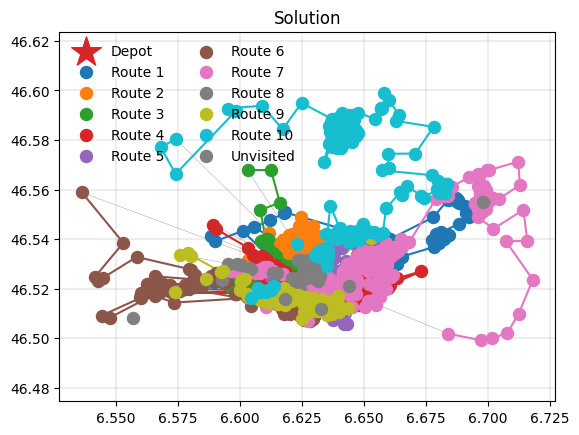

In [46]:
pyvrp.plotting.plot_solution(res.best, m.data(), plot_clients=True)

/var/folders/y4/pm_6h9w15m1b0tj16zjzv8xw0000gp/T/ipykernel_29247/548446692.py:36: RuntimeWarning: Couldn't reach some vertices. Location: src/paths/dijkstra.c:555
  path_ig = g_ig.get_shortest_paths(from_ig_node, to=to_ig_node, weights="length", output="vpath")[0]
/Users/hugosolleder/Code/pdptw/.venv/lib/python3.11/site-packages/osmnx/plot.py:352: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(od_x, od_y, s=orig_dest_size, c=route_color, alpha=route_alpha, edgecolor="none")


IndexError: list index out of range

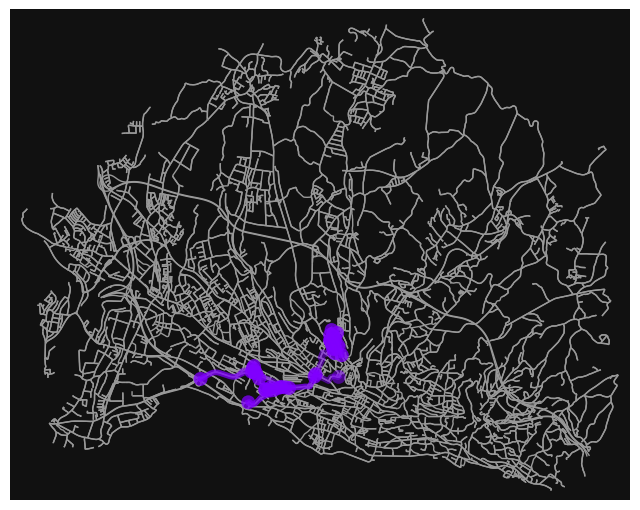

In [47]:
import matplotlib.cm as cm

# 1. Map VRP location indices to igraph node indices
# In pyvrp, location 0 is the depot, and locations 1..N are the clients in order of addition
loc_to_ig = [depot_osm_node_ig] 
for _, row in node_df.iterrows():
    if not row["isdepot"]:
        loc_to_ig.append(row["node_ig"])

# 2. Map igraph node indices back to NetworkX/OSM node IDs
ig_to_nx = {v: k for k, v in idx_maps["node_nx_to_ig"].items()}

all_paths_nx = []
route_colors = []

# 3. Iterate through all routes in the solution
routes = res.best.routes()
for r_idx, route in enumerate(routes):
    # Assign a unique color for this vehicle
    color = cm.rainbow(r_idx / max(len(routes), 1))
    
    for trip in route.trips():
        # Construct the sequence of locations (indices) for this trip
        # A trip starts at a depot, visits clients, and ends at a depot
        stops = [trip.start_depot()] + list(trip.visits()) + [trip.end_depot()]
        
        for i in range(len(stops) - 1):
            from_loc_idx = stops[i]
            to_loc_idx = stops[i+1]
            
            from_ig_node = loc_to_ig[from_loc_idx]
            to_ig_node = loc_to_ig[to_loc_idx]
            
            # Find the shortest path between these two nodes in the graph
            # output="vpath" gives the list of node indices in the path
            path_ig = g_ig.get_shortest_paths(from_ig_node, to=to_ig_node, weights="length", output="vpath")[0]
            
            # Convert igraph sequence to networkx/OSM sequence
            path_nx = [ig_to_nx[n] for n in path_ig]
            
            all_paths_nx.append(path_nx)
            route_colors.append(color)

# 4. Plot the routes on the graph
fig, ax = ox.plot_graph_routes(graph, all_paths_nx, route_colors=route_colors, route_linewidth=2, node_size=0)

In [ ]:
fig, ax = ox.plot_graph_routes(graph, all_paths_nx, route_colors=route_colors, route_linewidth=2, node_size=0)

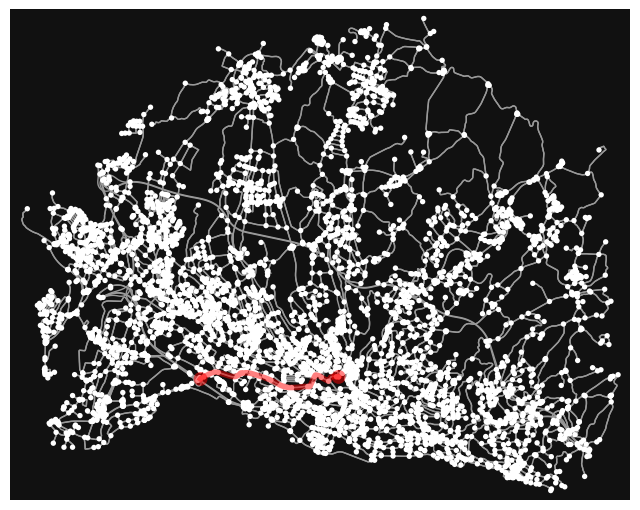

In [51]:
fig, ax = ox.plot_graph_route(graph, all_paths_nx[0])